# Tech Challenge - Predicao de Cancer de Mama (Wisconsin Diagnostic)

## Objetivo

Desenvolver um modelo de **Classificacao Binaria** para apoiar o diagnostico de **cancer de mama**, com base em caracteristicas de nucleos celulares extraidas de imagens de PAAF (Puncao Aspirativa por Agulha Fina).

**Dataset:** [Breast Cancer Wisconsin (Diagnostic)](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data) / UCI ML Repository

**Variavel alvo:** `diagnosis` (0 = Benigno, 1 = Maligno)

> Ferramenta de apoio a decisao. Nao substitui avaliacao medica, mamografia nem biopsia.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    f1_score,
)

%matplotlib inline

RANDOM_STATE = 42
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

## 1. Carregamento dos dados

In [2]:
df = pd.read_csv('breast_cancer_wisconsin.csv')
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

print(df.shape)
print(df.info())
df.head()

(569, 32)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   mean radius              569 non-null    float64
 2   mean texture             569 non-null    float64
 3   mean perimeter           569 non-null    float64
 4   mean area                569 non-null    float64
 5   mean smoothness          569 non-null    float64
 6   mean compactness         569 non-null    float64
 7   mean concavity           569 non-null    float64
 8   mean concave points      569 non-null    float64
 9   mean symmetry            569 non-null    float64
 10  mean fractal dimension   569 non-null    float64
 11  radius error             569 non-null    float64
 12  texture error            569 non-null    float64
 13  perimeter error          569 non-null    float64
 14  area error               56

,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,2,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,3,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,4,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,5,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 2. Analise Exploratoria (EDA)

In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64
Taxa maligna: 37.3%


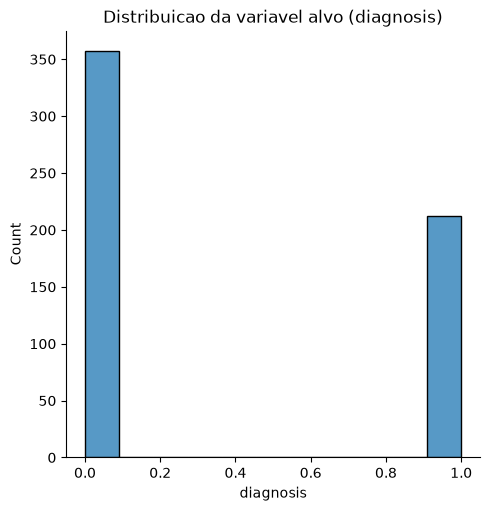

In [4]:
TARGET = 'diagnosis'
target_counts = df[TARGET].value_counts().sort_index()
print(target_counts.rename({0: 'Benigno', 1: 'Maligno'}))
print(f'Taxa maligna: {df[TARGET].mean():.1%}')

sns.displot(data=df[TARGET])
plt.title('Distribuicao da variavel alvo (diagnosis)')
plt.show()

In [5]:
df.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,285.000000,164.400426,1.000000,143.000000,285.000000,427.000000,569.00000
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


In [6]:
df.select_dtypes(include='number').head()

,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,2,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,3,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,4,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,5,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


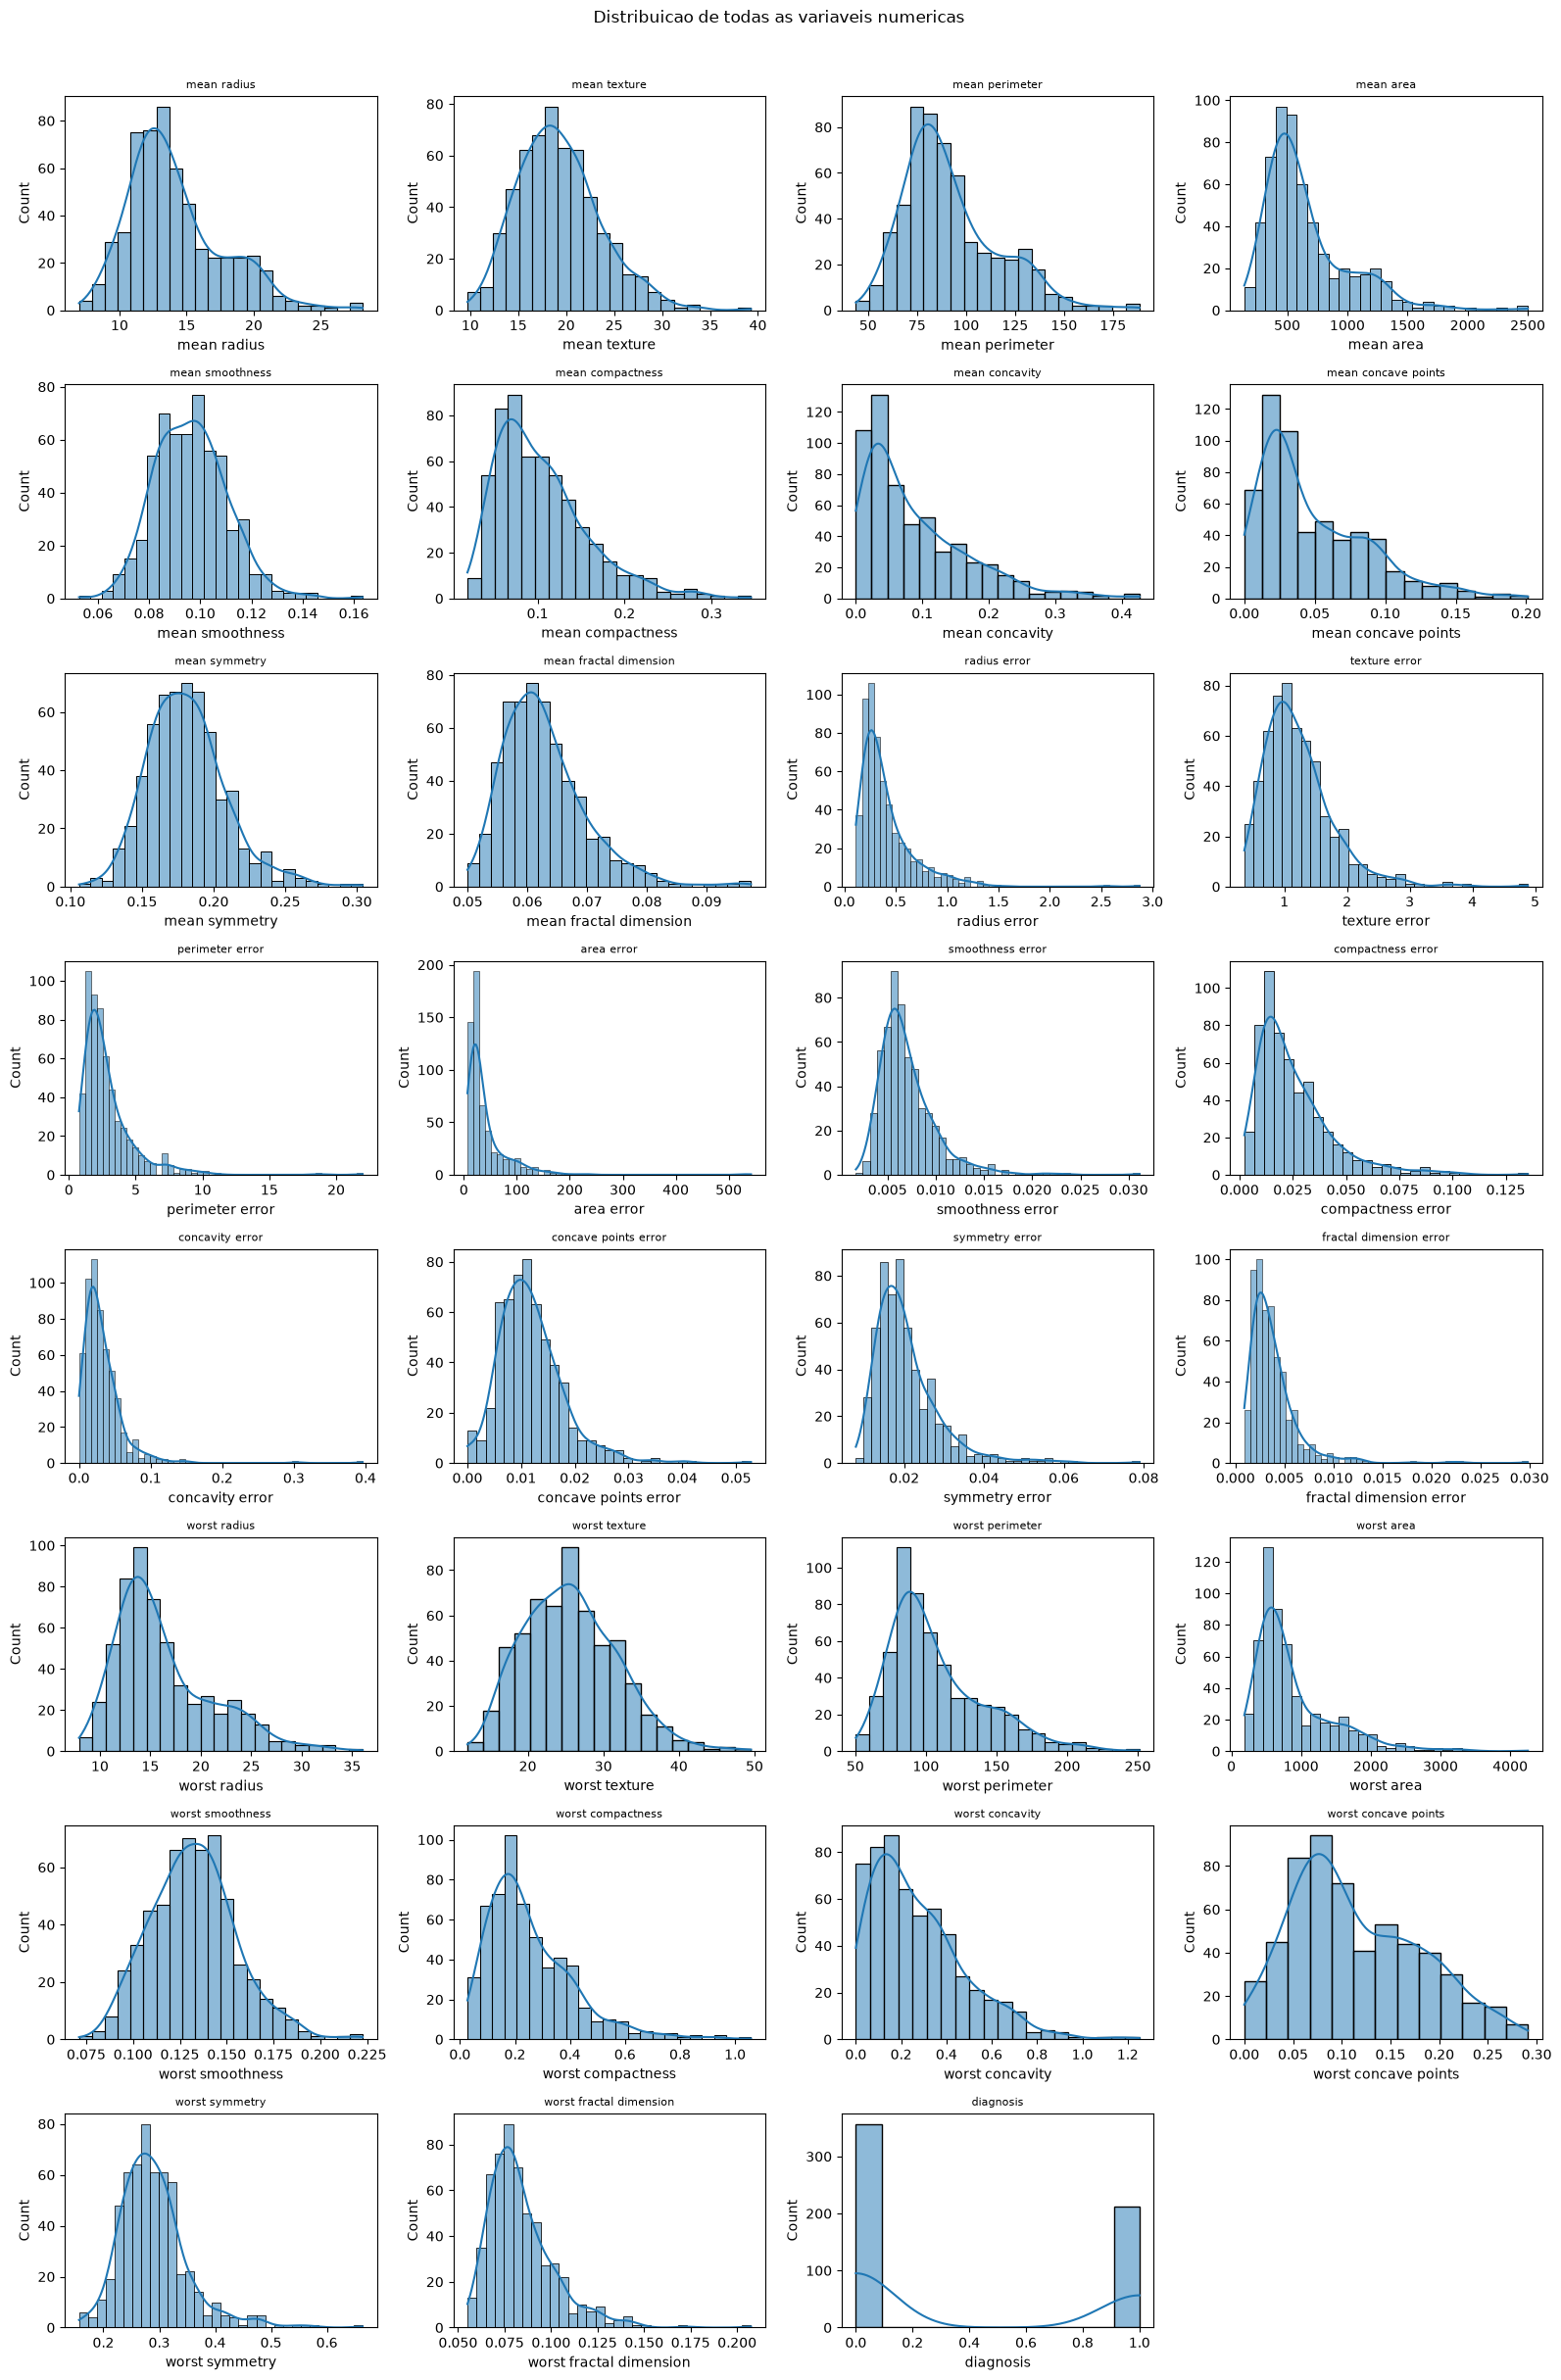

In [7]:
# Histograma de todas as variaveis numericas
numeric_cols = [c for c in df.columns if c not in ['id']]
ncols = 4
nrows = int(np.ceil(len(numeric_cols) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 3))
axes = np.array(axes).flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribuicao de todas as variaveis numericas', y=1.01)
plt.tight_layout()
plt.show()

### Graficos de dispersao (pairplot)

Subconjunto das 10 medidas `mean_*` para legibilidade visual.

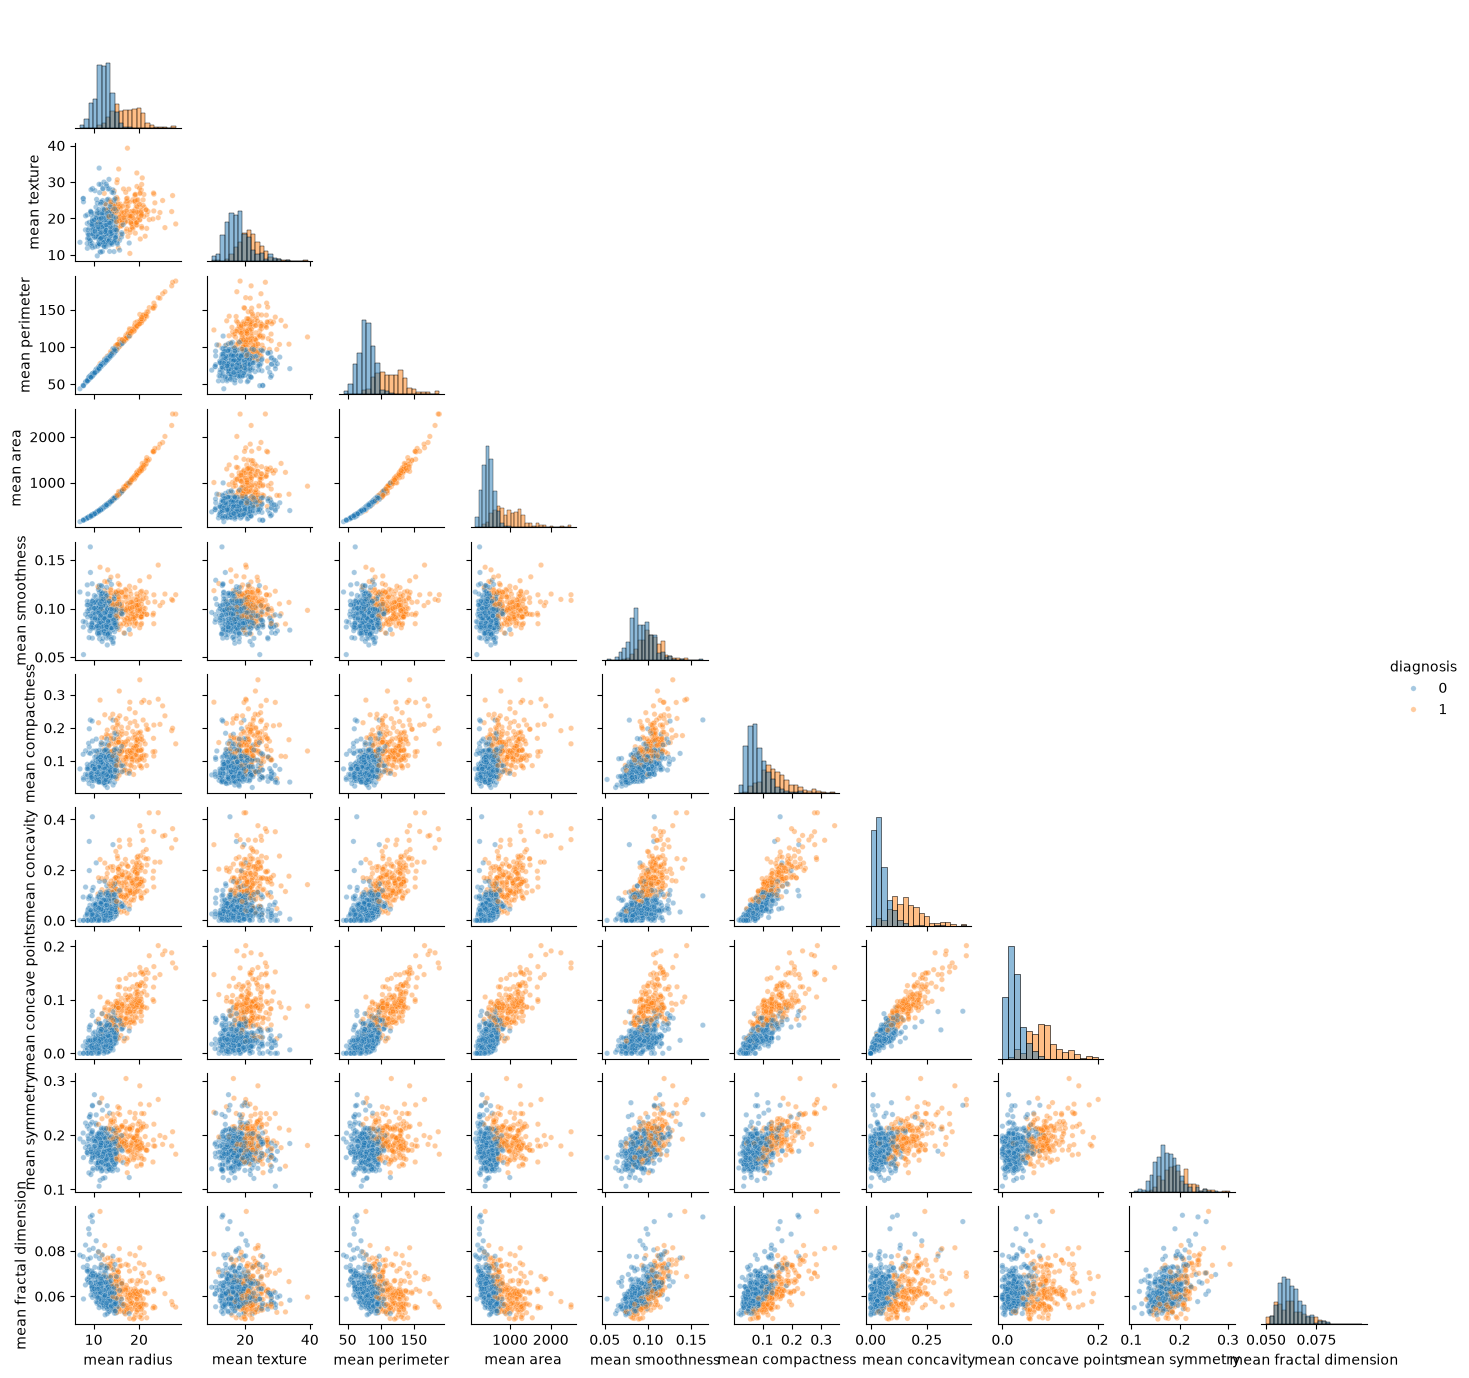

In [8]:
mean_cols = [c for c in df.columns if c.startswith('mean ')]
df_pair = df[mean_cols + [TARGET]]

sns.pairplot(
    df_pair,
    hue=TARGET,
    corner=True,
    diag_kind='hist',
    plot_kws={'alpha': 0.4, 's': 15},
    height=1.4,
)
plt.show()

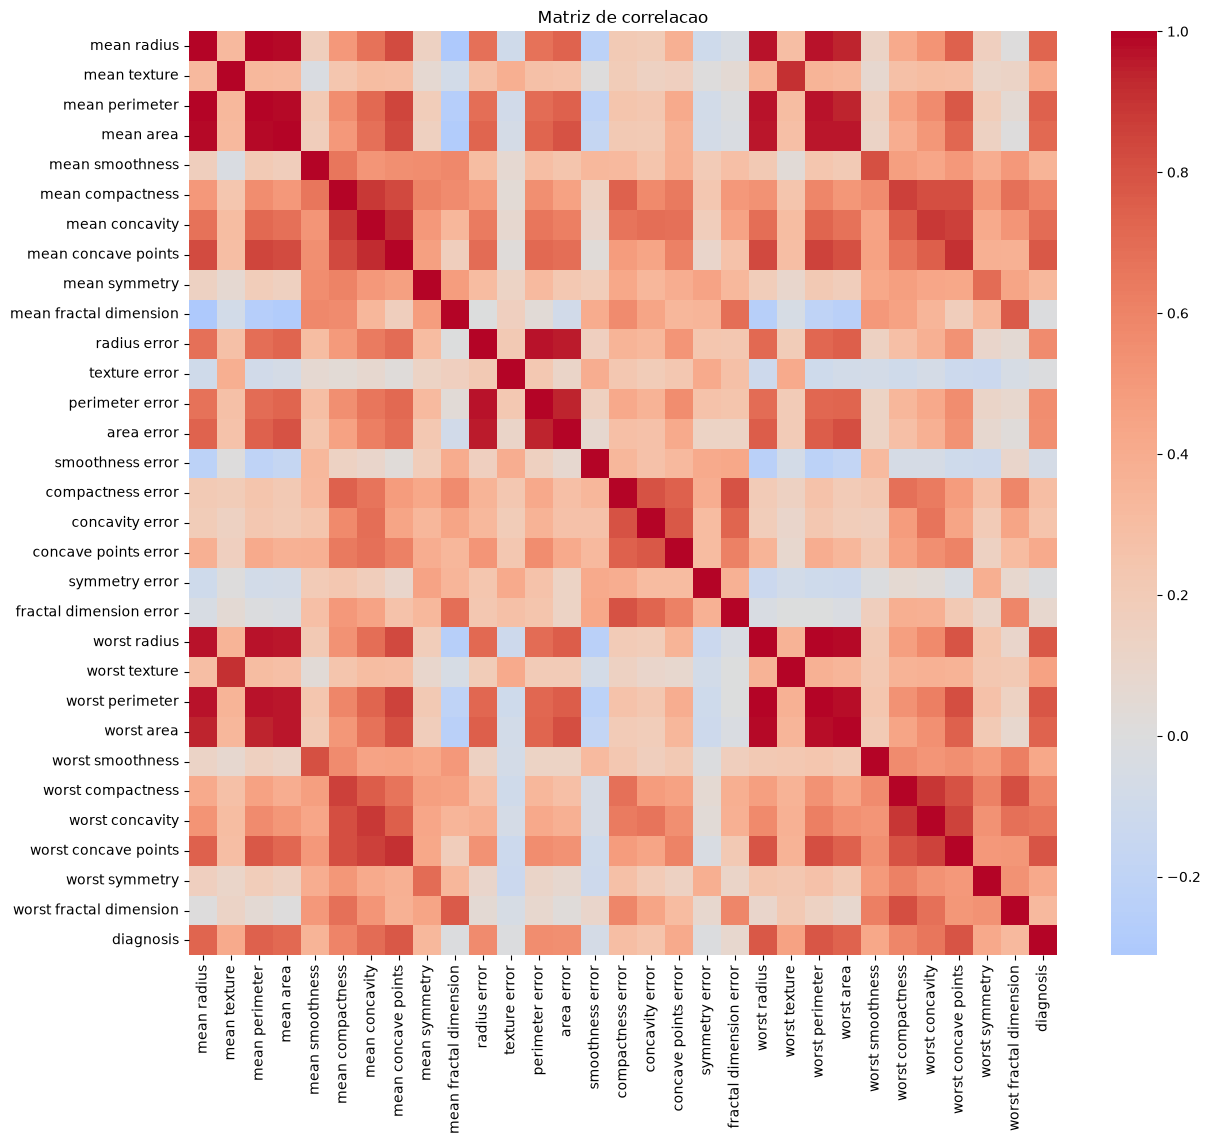

In [9]:
correlacao = df.select_dtypes(include='number').drop(columns=['id']).corr()
plt.figure(figsize=(14, 12))
sns.heatmap(correlacao, cmap='coolwarm', center=0)
plt.title('Matriz de correlacao')
plt.show()

## 3. Pre-processamento e definicao das features

In [10]:
FEATURE_COLS = [col for col in df.columns if col not in ['id', TARGET]]

x = df[FEATURE_COLS]
y = df[TARGET].astype(int)

print(f'Total de features: {len(FEATURE_COLS)}')
print('Distribuicao do alvo:')
print(y.value_counts().rename({0: 'Benigno', 1: 'Maligno'}))

Total de features: 30
Distribuicao do alvo:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), FEATURE_COLS),
    ]
)

## 4. Separacao treino / teste

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)

Treino: (455, 30) | Teste: (114, 30)


## 5. Treinar Modelo - Regressao Logistica

In [13]:
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
])

model_lr.fit(X_train, y_train)
predictions_lr = model_lr.predict(X_test)

## 6. Avaliacao de um modelo de classificacao

In [14]:
resultado = pd.DataFrame(
    zip(predictions_lr, y_test),
    columns=['prediction_lr', 'target']
)
print(resultado.shape)
resultado.head(20)

(114, 2)


,prediction_lr,target
0,0,0
1,1,1
2,0,0
3,1,1
4,1,0
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


In [15]:
resultado.loc[resultado.prediction_lr != resultado.target].shape

(3, 2)

## Matriz de confusao

- **VP:** Maligno previsto corretamente
- **VN:** Benigno previsto corretamente
- **FP:** Falso alarme (benigno classificado como maligno)
- **FN:** Falso negativo (maligno classificado como benigno)

[[71  1]
 [ 2 40]]


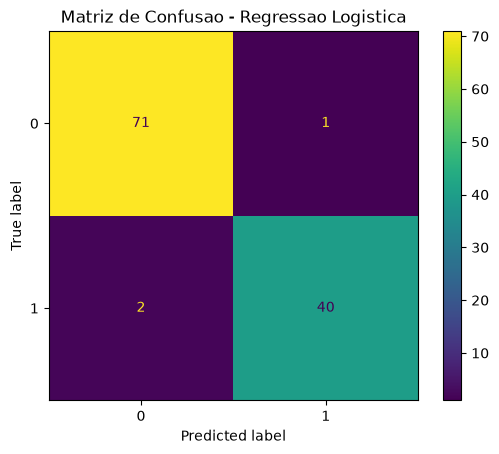

In [16]:
confusion_matrix_lr = confusion_matrix(y_test, predictions_lr)
print(confusion_matrix_lr)

cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_lr, display_labels=[0, 1])
cm_display.plot()
plt.title('Matriz de Confusao - Regressao Logistica')
plt.show()

In [17]:
print(classification_report(y_test, predictions_lr, target_names=['Benigno', 'Maligno']))

              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 7. Comparacao de algoritmos

In [18]:
classifiers = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE)),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=7, weights='distance')),
]

resultados = []

for model_name, classifier in classifiers:
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    resultados.append({
        'Modelo': model_name,
        'Accuracy': acc,
        'Recall': rec,
        'F1-Score': f1,
        'Pipeline': pipeline,
    })

    print(f'{model_name}: Accuracy={acc:.2f} | Recall={rec:.2f} | F1={f1:.2f}')

Logistic Regression: Accuracy=0.97 | Recall=0.95 | F1=0.96


Decision Tree: Accuracy=0.90 | Recall=0.83 | F1=0.86


Random Forest: Accuracy=0.97 | Recall=0.93 | F1=0.96


K-Nearest Neighbors: Accuracy=0.96 | Recall=0.90 | F1=0.94


In [19]:
resultado_df = pd.DataFrame(resultados).drop(columns='Pipeline')
resultado_df = resultado_df.sort_values(by='F1-Score', ascending=False)
resultado_df

,Modelo,Accuracy,Recall,F1-Score
0,Logistic Regression,0.973684,0.952381,0.963855
2,Random Forest,0.973684,0.928571,0.962963
3,K-Nearest Neighbors,0.956140,0.904762,0.938272
1,Decision Tree,0.903509,0.833333,0.864198


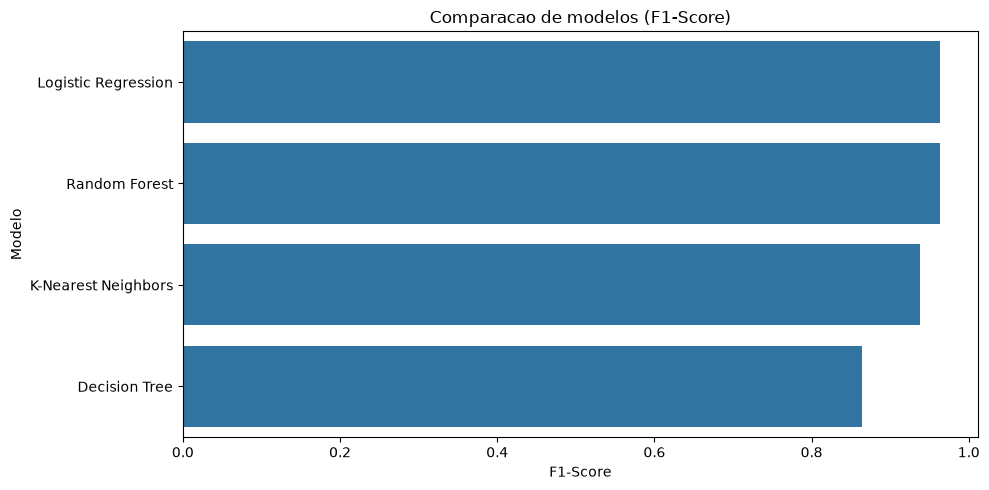

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(data=resultado_df, x='F1-Score', y='Modelo')
plt.title('Comparacao de modelos (F1-Score)')
plt.tight_layout()
plt.show()

## 8. Salvamento da pipeline para API REST

Melhor modelo pelo F1-Score salvo com `joblib` + metadados.

In [21]:
melhor = max(resultados, key=lambda r: r['F1-Score'])
best_pipeline = melhor['Pipeline']
best_name = melhor['Modelo']

print(f'Melhor modelo: {best_name}')
best_pipeline.fit(X_train, y_train)

MODEL_PATH = MODELS_DIR / 'pipeline_breast_cancer.pkl'
METADATA_PATH = MODELS_DIR / 'pipeline_metadata.pkl'

joblib.dump(best_pipeline, MODEL_PATH)
joblib.dump({
    'model_name': best_name,
    'feature_columns': FEATURE_COLS,
    'target_column': TARGET,
    'target_labels': {0: 'Benigno', 1: 'Maligno'},
    'dataset': 'breast_cancer_wisconsin.csv',
}, METADATA_PATH)

print(f'Pipeline salva em: {MODEL_PATH.resolve()}')
print(f'Metadados salvos em: {METADATA_PATH.resolve()}')

Melhor modelo: Logistic Regression
Pipeline salva em: C:\development\desafio\models\pipeline_breast_cancer.pkl
Metadados salvos em: C:\development\desafio\models\pipeline_metadata.pkl


## 9. Teste de carga da pipeline (simulando API REST)

In [22]:
pipeline_carregada = joblib.load(MODEL_PATH)
metadata = joblib.load(METADATA_PATH)

amostra = X_test.head(3)
predicoes = pipeline_carregada.predict(amostra)
probabilidades = pipeline_carregada.predict_proba(amostra)

resposta_api = pd.DataFrame({
    'predicao': predicoes,
    'probabilidade_maligno': probabilidades[:, 1],
    'label': [metadata['target_labels'][p] for p in predicoes],
})

print('Modelo:', metadata['model_name'])
print('Colunas esperadas:', len(metadata['feature_columns']), 'features')
resposta_api

Modelo: Logistic Regression
Colunas esperadas: 30 features


,predicao,probabilidade_maligno,label
0,0,0.000535,Benigno
1,1,1.000000,Maligno
2,0,0.053610,Benigno


# 10. Relatorio Tecnico

Ver arquivo `RELATORIO_TECNICO.md`.